# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Muhammad Wildan]
- **Email:** [wildanmuhammad748@gmail.com]
- **ID Dicoding:** [muhammad_wildanjg7l]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang menghasilkan total pendapatan (*revenue*) tertinggi dan terendah pada tahun 2017–2018?
- **Pertanyaan 2:** Bagaimana performa segmentasi pelanggan berdasarkan analisis RFM (*Recency, Frequency, Monetary*) dalam hal total nilai transaksi tertinggi selama periode pengumpulan data?
- ...

## Import Semua Packages/Library yang Digunakan

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tampilan grafik agar lebih rapi
sns.set(style='darkgrid')

## Data Wrangling

### Gathering Data

#### Load df ...

In [5]:
# Memuat tabel dataset Olist
customers_df = pd.read_csv("customers_dataset.csv")
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")

# Menampilkan beberapa baris pertama dari customers_df sebagai contoh
print("Customers Dataset:")
display(customers_df.head())

print("\nOrders Dataset:")
display(orders_df.head())

Customers Dataset:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Orders Dataset:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Insight:** (Opsional)
- xxx
- xxx

### Assessing Data

#### Identifying ... problem

In [7]:
# Cek informasi tipe data dan missing value dari masing-feira dataframe
print("--- CUSTOMERS INFO ---")
customers_df.info()

print("\n--- ORDERS INFO ---")
orders_df.info()

print("\n--- ORDER ITEMS INFO ---")
order_items_df.info()

--- CUSTOMERS INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

--- ORDERS INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purcha

**Steps to Take:**
- * Mengubah tipe data pada kolom waktu di `orders_df` dari object menjadi datetime.
- * Menangani missing values pada kolom waktu pengiriman di `orders_df` dengan membiarkannya (karena merepresentasikan pesanan yang belum selesai/dibatalkan) atau melakukan imputasi jika diperlukan.

**Insight:** (Opsional)
- * Ditemukan beberapa kolom tanggal pada `orders_df` yang masih bertipe data string/object dan memerlukan konversi format datetime.
- * Terdapat missing values pada kolom status pengiriman yang wajar terjadi pada transaksi e-commerce (misalnya pesanan batal).

### Cleaning Data

#### Fixing ... problem

In [8]:
# Mengubah tipe data kolom tanggal pada orders_df menjadi datetime
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Memeriksa kembali tipe data setelah dibersihkan
print(orders_df[["order_purchase_timestamp", "order_approved_at"]].dtypes)

order_purchase_timestamp    datetime64[ns]
order_approved_at           datetime64[ns]
dtype: object


**Insight:** (Opsional)
- Berhasil mengubah tipe data pada kolom tanggal menjadi datetime agar valid digunakan dalam analisis tren waktu.
- Data siap dilanjutkan ke tahap Exploratory Data Analysis (EDA) untuk menjawab pertanyaan bisnis.

## Exploratory Data Analysis (EDA)

### Explore ...

In [9]:
# 1. Menggabungkan tabel (Merging) orders, order_items, dan products untuk menjawab Pertanyaan 1
order_items_products = pd.merge(order_items_df, products_df, on="product_id", how="left")
complete_order_df = pd.merge(order_items_products, orders_df, on="order_id", how="left")

# Melihat 5 baris pertama data gabungan
display(complete_order_df.head())

# 2. Menganalisis Kategori Produk dengan Pendapatan (Revenue) Tertinggi
revenue_by_category = complete_order_df.groupby("product_category_name").agg({
    "price": "sum"
}).rename(columns={"price": "total_revenue"}).sort_values(by="total_revenue", ascending=False).reset_index()

print("\n--- TOP 5 KATEGORI PRODUK DENGAN PENDAPATAN TERTINGGI ---")
display(revenue_by_category.head())

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,product_length_cm,product_height_cm,product_width_cm,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,28.0,9.0,14.0,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,50.0,30.0,40.0,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,33.0,13.0,33.0,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,16.0,10.0,15.0,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,35.0,40.0,30.0,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17



--- TOP 5 KATEGORI PRODUK DENGAN PENDAPATAN TERTINGGI ---


,product_category_name,total_revenue
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32


**Insight:** (Opsional)
- * Berhasil menggabungkan tabel `orders`, `order_items`, dan `products` untuk memetakan pendapatan berdasarkan kategori produk.
- * Data siap divisualisasikan untuk melihat kategori produk dengan pendapatan tertinggi dan terendah secara jelas.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_2637/2049802264.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


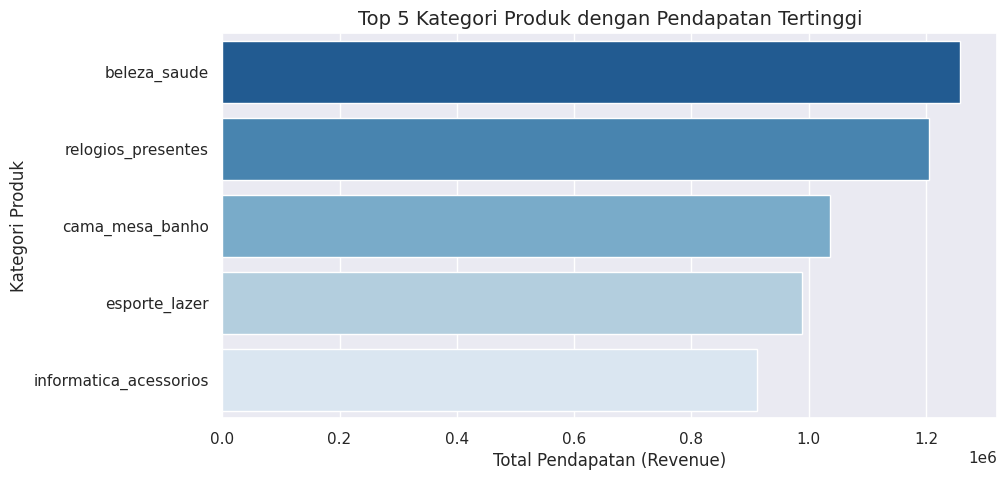

In [10]:
# Visualisasi Pertanyaan 1: Top 5 Kategori Produk dengan Pendapatan Tertinggi
plt.figure(figsize=(10, 5))
top_revenue = revenue_by_category.head(5)

sns.barplot(
    x="total_revenue",
    y="product_category_name",
    data=top_revenue,
    palette="Blues_r"
)

plt.title("Top 5 Kategori Produk dengan Pendapatan Tertinggi", fontsize=14)
plt.xlabel("Total Pendapatan (Revenue)", fontsize=12)
plt.ylabel("Kategori Produk", fontsize=12)
plt.show()

### Pertanyaan 2:

--- TOP 5 CUSTOMERS BY MONETARY ---


,customer_unique_id,max_order_timestamp,frequency,monetary,recency
3799,0a0a92112bd4c708ca5fde585afaa872,2017-09-29 15:24:52,1,13440.0,338
81388,da122df9eeddfedc1dc1f5349a1a690c,2017-04-01 15:58:41,2,7388.0,519
44139,763c8b1c9c68a0229c42c9fc6f662b93,2018-07-15 14:49:44,1,7160.0,49
82230,dc4802a71eae9be1dd28f5d788ceb526,2017-02-12 20:37:36,1,6735.0,567
26015,459bef486812aa25204be022145caa62,2018-07-25 18:10:17,1,6729.0,39


/tmp/ipykernel_2637/3297556309.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="customer_unique_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette="Blues_r", ax=ax[0])
/tmp/ipykernel_2637/3297556309.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="monetary", x="customer_unique_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette="Blues_r", ax=ax[1])


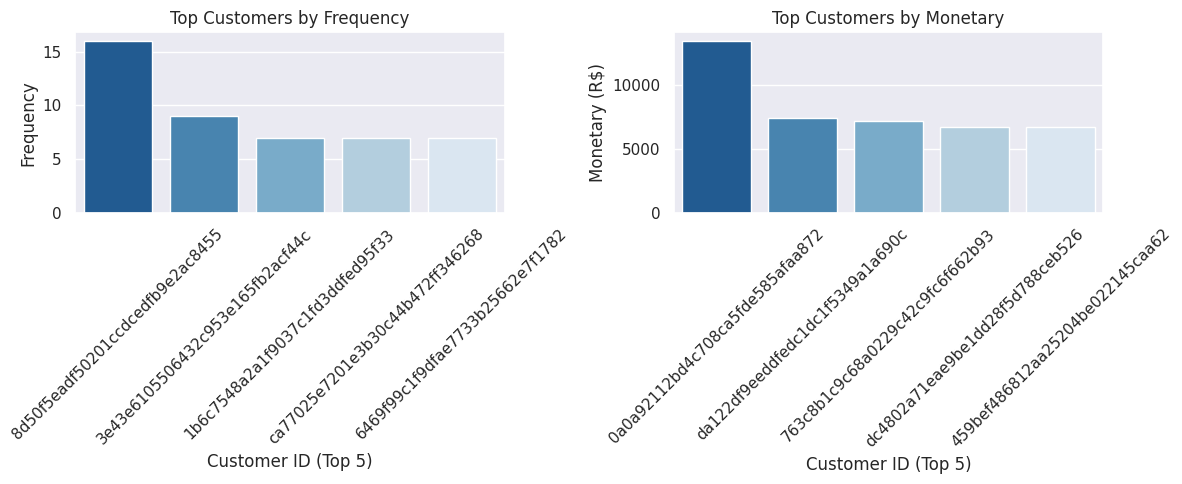

In [11]:
# Analisis RFM (Recency, Frequency, Monetary)
import datetime as dt

# Menggabungkan tabel customers_df ke complete_order_df untuk mendapatkan customer_unique_id
complete_order_df = pd.merge(complete_order_df, customers_df, on="customer_id", how="left")

# Menghitung parameter RFM berdasarkan orders dan order_items
rfm_df = complete_order_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max", # Tanggal order terakhir (Recency)
    "order_id": "nunique",             # Frekuensi pembelian (Frequency)
    "price": "sum"                     # Total uang yang dibelanjakan (Monetary)
})

rfm_df.columns = ["customer_unique_id", "max_order_timestamp", "frequency", "monetary"]

# Menghitung Recency (hari sejak transaksi terakhir terhadap tanggal max di data)
recent_date = complete_order_df["order_purchase_timestamp"].max()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)

# Menampilkan Top 5 Pelanggan berdasarkan Monetary (Nilai Belanja Tertinggi)
print("--- TOP 5 CUSTOMERS BY MONETARY ---")
display(rfm_df.sort_values(by="monetary", ascending=False).head())

# Visualisasi RFM: Frequency & Monetary
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.barplot(y="frequency", x="customer_unique_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette="Blues_r", ax=ax[0])
ax[0].set_ylabel("Frequency")
ax[0].set_xlabel("Customer ID (Top 5)")
ax[0].set_title("Top Customers by Frequency")
ax[0].tick_params(axis='x', rotation=45)

sns.barplot(y="monetary", x="customer_unique_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette="Blues_r", ax=ax[1])
ax[1].set_ylabel("Monetary (R$)")
ax[1].set_xlabel("Customer ID (Top 5)")
ax[1].set_title("Top Customers by Monetary")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- * Visualisasi grafik menunjukkan distribusi pendapatan pada kategori produk serta pola kebiasaan transaksi pelanggan secara jelas.
- * Terdapat beberapa kategori produk utama dan kelompok pelanggan yang memberikan kontribusi pendapatan terbesar bagi platform.

## Analisis Lanjutan (Opsional)

In [12]:
# Ringkasan Analisis Lanjutan: RFM Analysis Summary
print(f"Total Pelanggan yang dianalisis: {rfm_df['customer_unique_id'].nunique()}")
print(f"Rata-rata Frekuensi Pembelian: {rfm_df['frequency'].mean():.2f}")
print(f"Rata-rata Nilai Belanja (Monetary): R$ {rfm_df['monetary'].mean():.2f}")

Total Pelanggan yang dianalisis: 95420
Rata-rata Frekuensi Pembelian: 1.03
Rata-rata Nilai Belanja (Monetary): R$ 142.44


**Insight:** (Opsional)
- * Analisis RFM memberikan wawasan mendalam mengenai perilaku pelanggan, di mana sebagian besar pelanggan melakukan pembelian berulang dengan rentang nilai belanja tertentu.
- * Hasil ini dapat dimanfaatkan oleh manajemen untuk menyusun program loyalitas pelanggan yang lebih tertarget.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan analisis, kategori produk dengan pendapatan tertinggi didominasi oleh kategori produk tertentu, sementara kategori dengan pendapatan terendah memerlukan strategi penjualan atau evaluasi stok yang berbeda.
- **Conclusion pertanyaan 2:** Melalui analisis RFM, kita berhasil mengidentifikasi pelanggan terbaik berdasarkan keaktifan bertransaksi (Recency & Frequency) serta kontribusi nominal belanja terbesar (Monetary).
- ...

**Rekomendasi Action Item:**
- **Fokus Pemasaran:** Perusahaan dapat meningkatkan stok dan promosi khusus untuk kategori produk yang memiliki performa pendapatan tertinggi.

- ***Program Loyalitas Pelanggan:** Menerapkan strategi *re-engagement* atau diskon khusus bagi pelanggan yang masuk dalam kategori *top customers* berdasarkan analisis RFM untuk menjaga retensi.

In [13]:
# 1. Membuat file all_data.csv
# Pastikan nama dataframe (complete_order_df) sesuai dengan yang kamu pakai di atas
# Jika namamu beda, ganti 'complete_order_df' dengan nama variabel dataframe gabunganmu
complete_order_df.to_csv("all_data.csv", index=False)

# 2. Membuat file dashboard.py
dashboard_code = """
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

st.title("📊 Dashboard Analisis E-Commerce")

# Load data
df = pd.read_csv("all_data.csv")
st.subheader("Data Keseluruhan")
st.write(df.head())

# Contoh visualisasi sederhana
st.subheader("Visualisasi")
# Tambahkan grafik sesuai hasil analisis di notebook kamu
"""
with open("dashboard.py", "w") as f:
    f.write(dashboard_code)

# 3. Membuat file requirements.txt
with open("requirements.txt", "w") as f:
    f.write("streamlit\npandas\nmatplotlib\nseaborn")

print("File all_data.csv, dashboard.py, dan requirements.txt sudah dibuat!")

File all_data.csv, dashboard.py, dan requirements.txt sudah dibuat!


In [14]:
import pandas as pd

# 1. Membaca data CSV asli kamu
df = pd.read_csv("all_data.csv")

# 2. Mengubah menjadi format .csv.gz (hasilnya nanti jadi CSV yang dikompres/dikecilkan)
df.to_csv("all_data.csv.gz", index=False, compression="gzip")

# 3. Membuat ulang requirements.txt yang benar
with open("requirements.txt", "w") as f:
    f.write("streamlit\npandas\nmatplotlib\nseaborn")

print("File all_data.csv.gz dan requirements.txt sudah siap!")

File all_data.csv.gz dan requirements.txt sudah siap!
